# Cosine Schedule with Continuous Time

## Complete Beginner's Guide

This notebook introduces an important improvement to diffusion models: using **continuous time** with a **cosine schedule** instead of discrete timesteps.

### What You'll Learn

1. **Continuous vs Discrete Time**: Why continuous is often better
2. **Cosine Schedule**: A better noise schedule than linear
3. **Simplified Formulas**: Using t in [0,1] instead of t in {0,1,...,999}
4. **Direct Denoising**: Estimating clean images from noisy ones
5. **DDIM with Continuous Time**: Faster sampling

### Prerequisites
- Basic Python knowledge
- Understanding of DDPM and DDIM from previous notebooks

### Discrete vs Continuous Time

```
DISCRETE (previous notebooks):
- t is an integer: 0, 1, 2, ..., 999
- alphabar is a lookup table: alphabar[t]
- Fixed number of steps

CONTINUOUS (this notebook):
- t is a real number: 0.0 to 1.0
- alphabar is a function: abar(t)
- Can use any number of steps
- More flexible and often simpler
```

## Google Colab Setup

Run the cells below **once** at the start of each Colab session. They mount Google Drive, set the working directory, install required packages, and clone the `miniai` library from the fast.ai Part 2 course repo.

**GPU note:** Cosine-schedule training cells need a GPU. **Runtime &rarr; GPU**.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
os.chdir('/content/drive/MyDrive/Fast.AI_Colab')
print(os.getcwd())

/content/drive/MyDrive/Fast.AI_Colab


In [3]:
!pip install -q fastcore fastai diffusers datasets torcheval accelerate wandb
if not os.path.exists('course22p2'):
    !git clone https://github.com/fastai/course22p2.git
import sys
sys.path.insert(0, os.path.join(os.getcwd(), 'course22p2'))
try:
    import miniai
    print(f'miniai loaded from: {miniai.__file__}')
except ImportError:
    print('ERROR: miniai not found.')

miniai loaded from: /content/drive/MyDrive/Fast.AI_Colab/course22p2/miniai/__init__.py


---

*The cells above are Colab-specific setup. The content below is the same as the source notebook (`22_cosine_explained.ipynb`), unchanged.*

---

---
## 🎮 Interactive Visualizations in This Notebook

This notebook includes **8 interactive visualizations** (hosted on GitHub Pages, embedded below in full-width auto-sizing iframes). Each one has **stage chips** that animate one idea at a time and sync the highlighted code, plus **play / step / speed** controls. Click things — dots, drawers, pillars, bars, and plots are clickable.

| # | Visualization | What it teaches | Where |
|---|---------------|-----------------|-------|
| 1 | **Two Worlds of Time** | discrete lookup table (nb 19) vs continuous `abar(t)` function | right below |
| 2 | **Building cos²(πt/2)** | the schedule from a spinning angle; √ᾱ=cos, √(1−ᾱ)=sin; `inv_abar` backwards | after the schedule code |
| 3 | **Schedule Landscape (3D)** | ride the cosine ribbon; why the 1000-slab staircase can't answer between steps | after ↑2 |
| 4 | **The noisify Machine** | five stations, the new `rand` dice, the `clamp(0, 0.999)` guard, broadcasting | after noisify |
| 5 | **Direct Denoising Lab** | solve for x₀; the ÷√ᾱ error amplifier; why high-t reconstructions blur | after denoise |
| 6 | **ddim_step Anatomy** | σ and η, x̂₀ + clamp(±1.5), the σ=0 guard, three streams recombining | after ddim_step |
| 7 | **The sample() Loop** | the linspace rail, any step count, the final-step ᾱ=1 guard, steps-vs-FID | after sample |
| 8 | **The ×2 Range Journey** | why `preds[-1] * 2` — model world [−0.5,0.5] vs FID world [−1,1] | after sampling |

> **Tip:** run the setup cell below once, then each 🎮 cell works independently.

In [4]:
# ============================================================================
# INTERACTIVE VISUALIZATIONS -- setup (run this cell ONCE).
# Each "🎮 Interactive" cell below loads a standalone HTML file from the
# published copy on GitHub Pages, in an isolated <iframe> (its CSS/JS can't leak
# into the notebook). It is shown FULL WIDTH and auto-fits its content height.
# No local files needed -- the visualizations are read from GitHub.
# ============================================================================
from IPython.display import HTML

def show_viz(path, height="600px"):
    """Embed an interactive visualization full width; it auto-fits its height.
    `path` may be a bare 'interactive_viz/<file>.html' (resolved to the GitHub
    Pages copy) or a full https URL."""
    base = "https://shammun.github.io/shammunul-fastai-notes/notebooks/"
    if not path.startswith("http"):
        path = base + path
    return HTML(
        f'<iframe src="{path}" loading="lazy" allowfullscreen '
        f'style="width:100%;height:{height};border:1px solid #dde5f2;border-radius:12px;'
        f'box-shadow:0 8px 24px rgba(123,92,214,.12);background:#fff;"></iframe>'
        '<script>addEventListener("message",function(e){'
        'if(e.data&&e.data.type==="ce-frame-height"&&e.data.height>50){'
        'var fs=document.querySelectorAll("iframe");for(var i=0;i<fs.length;i++){'
        'if(fs[i].contentWindow===e.source){fs[i].style.height=e.data.height+"px";break;}}}});</script>'
    )

### 🎮 Interactive: Two Worlds of Time

The single biggest change in this notebook, on one screen — nb 19's **1000-drawer lookup cabinet** vs this notebook's **one-line function**:

**What to try**
- **Drag the timeline** (or drag directly on either panel): both worlds answer the same question "how much signal at time t?" — watch the cabinet open drawer `round(999·t)` while the function just evaluates `cos²`.
- Chip **③ Ask between the drawers** parks t at 0.6175 — drawer 617.5 doesn't exist (red ✗), but `abar(0.6175)` answers instantly. This is *the* reason continuous time exists.
- Chip **④ Why it matters** shows one trained model sampled on 100 / 50 / 25-step rails — the payoff you'll measure with FID at the end of the notebook.

In [5]:
show_viz("interactive_viz/cos22_big_picture.html", height="820px")

---
## Setup and Imports

In [6]:
# Select GPU (change to '0' if you only have one GPU)
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

In [7]:
%%capture
!pip install -q --force-reinstall "numpy<2" 2>/dev/null

In [8]:
# Main imports
import timm, torch, random, datasets, math
import fastcore.all as fc
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import k_diffusion as K  # k-diffusion library for advanced diffusion techniques
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import torch.nn.functional as F

from torch.utils.data import DataLoader, default_collate
from pathlib import Path
from torch.nn import init
from fastcore.foundation import L
from torch import nn, tensor
from datasets import load_dataset
from operator import itemgetter
from torcheval.metrics import MulticlassAccuracy
from functools import partial
from torch.optim import lr_scheduler
from torch import optim

# miniai modules
from miniai.datasets import *
from miniai.conv import *
from miniai.learner import *
from miniai.activations import *
from miniai.init import *
from miniai.sgd import *
from miniai.resnet import *
from miniai.augment import *
from miniai.accel import *

In [9]:
# Progress bar and HuggingFace diffusers
from fastprogress import progress_bar
from diffusers import UNet2DModel, DDIMPipeline, DDPMPipeline, DDIMScheduler, DDPMScheduler

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [10]:
# Configure PyTorch and matplotlib
torch.set_printoptions(precision=4, linewidth=140, sci_mode=False)
torch.manual_seed(1)  # For reproducibility
mpl.rcParams['image.cmap'] = 'gray_r'  # Grayscale colormap
mpl.rcParams['figure.dpi'] = 70  # Figure resolution

# Suppress warnings
import logging
logging.disable(logging.WARNING)

# Set random seed
set_seed(42)

# Limit CPU workers
if fc.defaults.cpus > 8:
    fc.defaults.cpus = 8

---
## Load Dataset

In [11]:
# Dataset configuration
xl, yl = 'image', 'label'  # Column names
name = "zalando-datasets/fashion_mnist"     # Dataset name
bs = 512                   # Batch size

# Load dataset
dsd = load_dataset(name)

README.md:   0%|          | 0.00/9.02k [00:00<?, ?B/s]

fashion_mnist/train-00000-of-00001.parqu(…): reconstructing file:   0%|          |  0.00B / 30.9MB            

fashion_mnist/train-00000-of-00001.parqu(…): downloading bytes:           |  0.00B            

fashion_mnist/test-00000-of-00001.parque(…): reconstructing file:   0%|          |  0.00B / 5.18MB            

fashion_mnist/test-00000-of-00001.parque(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

---
## The Cosine Schedule with Continuous Time

This is the key innovation of this notebook. Instead of using discrete timesteps (0, 1, 2, ..., 999), we use continuous time t in the range [0, 1].

### The Cosine Formula

The cosine schedule for alphabar is:

$$\bar{\alpha}(t) = \cos^2\left(\frac{\pi t}{2}\right)$$

Where:
- t = 0: $\bar{\alpha} = \cos^2(0) = 1$ (pure signal, no noise)
- t = 1: $\bar{\alpha} = \cos^2(\pi/2) = 0$ (pure noise, no signal)

In [12]:
# Now, we assume that our time step is between 0 and 1
# At time t=0 is all clean and t=1 is all noise
def abar(t):
    """
    Cosine schedule for alphabar.

    This function computes the signal preservation factor at time t.

    Args:
        t: Time value(s) in range [0, 1]
           Can be a scalar or tensor

    Returns:
        alphabar(t) = cos^2(t * pi / 2)

    Properties:
        - abar(0) = 1 (full signal at start)
        - abar(1) = 0 (no signal at end)
        - Smooth transition between
    """
    return (t * math.pi / 2).cos() ** 2

# Calculate t or the inverse of abar
# Calculate time t given the image
def inv_abar(x):
    """
    Inverse of the abar function.

    Given an alphabar value, find the corresponding time t.

    Args:
        x: alphabar value(s) in range [0, 1]

    Returns:
        t such that abar(t) = x

    Derivation:
        x = cos^2(t * pi / 2)
        sqrt(x) = cos(t * pi / 2)
        acos(sqrt(x)) = t * pi / 2
        t = acos(sqrt(x)) * 2 / pi
    """
    return x.sqrt().acos() * 2 / math.pi

**Visualizing the cosine schedule:**

```
alphabar
   1 |*                      
     | *                     
     |  **                   
     |    **                 
 0.5 |      ***              
     |         ***           
     |            ****       
     |                *****  
   0 +---------------------*
     0        0.5          1
                  t

At t=0: alphabar=1 (pure signal)
At t=0.5: alphabar=0.5 (half signal, half noise)
At t=1: alphabar=0 (pure noise)
```

**Why use continuous time?**

1. **Simpler code**: No need for lookup tables
2. **Flexible sampling**: Use any number of steps
3. **Smoother transitions**: Better interpolation between steps
4. **Mathematical elegance**: Cleaner formulas

### 🎮 Interactive: Building cos²(πt/2)

Where the formula comes from — not memorized, *constructed*, one chip at a time:

**What to try**
- Walk the chips: **① t→angle → ② cos = signal knob → ③ square → ᾱ → ④ the Pythagoras trick → ⑤ inv_abar backwards**. Each chip adds one curve to the plot and highlights the matching piece of the one-liner.
- **Drag t** on the quarter-circle *or* on the plot — the mixed image at the bottom is honestly recomputed as √ᾱ·x₀ + √(1−ᾱ)·ε.
- Chip **④** is the payoff: √ᾱ = cos θ and √(1−ᾱ) = sin θ, so cos²+sin²=1 guarantees **signal² + noise² = 1 at every t** (watch the energy bar — it can never overflow).
- Chip **⑤** animates `inv_abar`: enter at an ᾱ height, hit the curve, drop down to read t — the three "undos" (√, acos, ×2/π) in reverse order.

In [13]:
show_viz("interactive_viz/cos22_schedule_lab.html", height="800px")

### 🎮 Interactive (3D): The Schedule Landscape

The same idea as terrain — **drag to rotate, scroll to zoom**:

**What to try**
- **Ride the ribbon** (chip ②): the orange courier's face is recomputed every frame from the actual mix formula — watch the shirt dissolve as ᾱ descends, and the twin √ᾱ / √(1−ᾱ) bars over its head trade places (they cross at t=0.5).
- Click the **teal milestone pillars** (or the pills below the scene) to jump to t = 0, 0.2, …, 0.99 and read what's special at each stop.
- Chip **③** parks the courier at t=0.6175: on the ribbon, no problem — but the red dashed line falls *between* two slabs of the discrete staircase behind. Toggle **🪜 discrete staircase** on/off to compare shapes: linear-1000 has already destroyed far more signal by mid-run.
- Chip **④** runs `inv_abar` as an elevator: beam in at height ᾱ, drop down to the floor, read off t.

In [14]:
show_viz("interactive_viz/cos22_landscape_3d.html", height="800px")

---
## Noisify Function with Continuous Time

The noisify function adds noise to clean images. With continuous time, we sample t from a uniform distribution on [0, 1) instead of integers.

In [15]:
def noisify(x0):
    """
    Add noise to clean images using continuous time cosine schedule.

    The forward diffusion formula is the same:
        x_t = sqrt(abar(t)) * x_0 + sqrt(1 - abar(t)) * epsilon

    But now t is sampled continuously from [0, 1) instead of {0, 1, ..., 999}.

    Args:
        x0: Clean images, shape (batch, channels, height, width)

    Returns:
        ((noisy_images, t), noise)
        - noisy_images: Images with noise added
        - t: Continuous time values (not integers!)
        - noise: The epsilon that was added
    """
    device = x0.device
    n = len(x0)  # Batch size

    # Previously, in 19_DDPM_v3.ipynb, time step was
    # t = torch.randint(0, n_steps, (n,), dtype=torch.long)

    # Sample random continuous time values
    # torch.rand gives values in [0, 1)
    # .clamp(0, 0.999) avoids t=1 (pure noise, uninformative)
    t = torch.rand(n,).to(x0).clamp(0, 0.999)
    # It creates a batch of n random probabilities (floats) matched
    # to x0's hardware and type, while ensuring none of them ever
    # reach exactly 1.0 to prevent math errors

    # Generate random Gaussian noise
    epsilon = torch.randn(x0.shape, device=device)
    # It generates a tensor of Gaussian noise (random values centered
    # at 0) with the exact same dimensions and hardware placement as
    # your input data x0, ready to be added to it.

    # Previously, we calculated
    # ᾱ_t = ᾱ[t].reshape(-1, 1, 1, 1).to(device)
    # Compute alphabar at each time t
    # Reshape for broadcasting: (n,) -> (n, 1, 1, 1)
    abar_t = abar(t).reshape(-1, 1, 1, 1).to(device)

    # Previously, this was
    # xt = ᾱ_t.sqrt()*x0 + (1-ᾱ_t).sqrt()*ε
    # Forward diffusion formula
    # x_t = sqrt(abar_t) * x_0 + sqrt(1 - abar_t) * epsilon
    xt = abar_t.sqrt() * x0 + (1 - abar_t).sqrt() * epsilon

    return (xt, t.to(device)), epsilon

Previously, noisify was like this inside 19_DDPM_v3.ipynb:

```python
def noisify(x0, ᾱ):
    device = x0.device
    n = len(x0)
    t = torch.randint(0, n_steps, (n,), dtype=torch.long)
    ε = torch.randn(x0.shape, device=device)
    ᾱ_t = ᾱ[t].reshape(-1, 1, 1, 1).to(device)
    xt = ᾱ_t.sqrt()*x0 + (1-ᾱ_t).sqrt()*ε
    return (xt, t.to(device)), ε
```

**Key difference from discrete version:**

```python
# DISCRETE (previous notebooks):
t = torch.randint(0, n_steps, (n,), dtype=torch.long)  # Integers 0-999
abar_t = alphabar[t]  # Lookup table

# CONTINUOUS (this notebook):
t = torch.rand(n,).clamp(0, 0.999)  # Floats 0.0-0.999
abar_t = abar(t)  # Function call
```

The model now receives continuous t values and must learn to handle any t, not just specific discrete values.

### 🎮 Interactive: The noisify Machine

The function above as a five-station assembly line — with the nb 19 version alongside for a line-by-line diff:

**What to try**
- **▶ Run batch** sends 5 images through; each station lights up its line in *both* code panels (teal = new in nb 22, red = the nb 19 line it replaced).
- **Click any station** (or chip) to zoom in: station ② rolls the new float dice (`rand` → 0.52, 0.81… vs `randint` → 517, 810…), station ③ shows the `clamp(0, 0.999)` ceiling and the ÷0 disaster it prevents, station ④ shows the `(n,) → (n,1,1,1)` reshape as stretchy broadcast dims.
- **🎲 re-roll** draws fresh t and ε — notice each image always keeps *its own* noise level in station ⑤.

In [16]:
show_viz("interactive_viz/cos22_noisify_machine.html", height="860px")

In [17]:
def collate_ddpm(b):
    """
    Custom collate function for DDPM with continuous time.
    """
    return noisify(default_collate(b)[xl])


def dl_ddpm(ds):
    """
    Create DataLoader for DDPM training.
    """
    return DataLoader(ds, batch_size=bs, collate_fn=collate_ddpm, num_workers=4)

In [18]:
# Transform: convert to tensor, pad 28x28 -> 32x32, center around 0
@inplace
def transformi(b):
    b[xl] = [F.pad(TF.to_tensor(o), (2,2,2,2)) - 0.5 for o in b[xl]]

# Apply transform and create DataLoaders
tds = dsd.with_transform(transformi)
dls = DataLoaders(dl_ddpm(tds['train']), dl_ddpm(tds['test']))

"""
# Dataset configuration
xl, yl = 'image', 'label'  # Column names
name = "zalando-datasets/fashion_mnist"     # Dataset name
bs = 512                   # Batch size

# Load dataset
dsd = load_dataset(name)
"""

# Get a sample batch
dl = dls.train
(xt, t), eps = b = next(iter(dl))
# both (xt, t), eps and b get the value returned by next(iter(dl))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


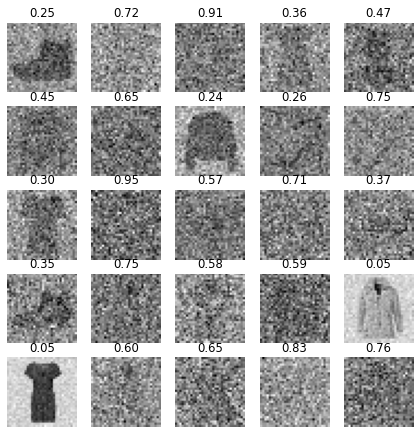

In [19]:
# Display noisy images with their continuous time values
# Note: t values are now decimals like 0.23, 0.87, etc.
show_images(xt[:25], imsize=1.5, titles=fc.map_ex(t[:25], '{:.02f}'))

**Notice the time values**: Instead of integers (517, 810, 839...), you now see decimals (0.52, 0.81, 0.84...).

- t ≈ 0.00-0.20: Mostly clean, slight noise
- t ≈ 0.40-0.60: Partial visibility
- t ≈ 0.80-0.99: Mostly noise

---
## Model Setup

In [20]:
class UNet(UNet2DModel):
    """
    UNet wrapper that:
    1. Unpacks (image, t) tuple
    2. Extracts .sample from output

    Note: The UNet2DModel can handle both discrete and continuous time.
    It uses sinusoidal embeddings that work with any t value.
    """
    def forward(self, x):
        return super().forward(*x).sample

In [21]:
def init_ddpm(model):
    """
    Initialize UNet for stable DDPM training.

    - Zero out final convs in residual blocks
    - Orthogonal init for downsamplers
    - Zero out final output conv
    """
    for o in model.down_blocks:
        for p in o.resnets:
            p.conv2.weight.data.zero_()
        for p in fc.L(o.downsamplers):
            init.orthogonal_(p.conv.weight)

    for o in model.up_blocks:
        for p in o.resnets:
            p.conv2.weight.data.zero_()

    model.conv_out.weight.data.zero_()

---
## Training

In [22]:
# Training hyperparameters
lr = 4e-3       # Learning rate (higher than before)
epochs = 10     # Number of epochs

# Optimizer (Adam instead of AdamW)
opt_func = partial(optim.Adam, eps=1e-5)

# Learning rate scheduler
tmax = epochs * len(dls.train)
sched = partial(lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax)

# Callbacks
cbs = [
    DeviceCB(),
    MixedPrecision(),
    ProgressCB(plot=True),
    MetricsCB(),
    BatchSchedCB(sched)
]

# Create model
model = UNet(
    in_channels=1,
    out_channels=1,
    block_out_channels=(32, 64, 128, 256),
    norm_num_groups=8
)
init_ddpm(model)

# Create Learner
learn = Learner(model, dls, nn.MSELoss(), lr=lr, cbs=cbs, opt_func=opt_func)

/content/drive/MyDrive/Fast.AI_Colab/course22p2/miniai/accel.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  def before_fit(self, learn): self.scaler = torch.cuda.amp.GradScaler()


loss,epoch,train
0.346,0,train
0.064,0,eval
0.057,1,train
0.052,1,eval
0.048,2,train
0.045,2,eval
0.043,3,train
0.041,3,eval
0.040,4,train
0.039,4,eval


/content/drive/MyDrive/Fast.AI_Colab/course22p2/miniai/sgd.py:20: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  if learn.training: self.schedo.step()


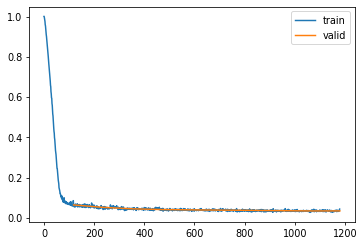

In [23]:
# Train the model
learn.fit(epochs)

In [25]:
# Save/load model
torch.save(learn.model, 'models/fashion_cos.pkl')

In [26]:
# Save/load model
# torch.save(learn.model, 'models/fashion_cos.pkl')
model = learn.model = torch.load('models/fashion_cos.pkl', weights_only=False).cuda()

---
## Direct Denoising

Given a noisy image x_t and the predicted noise, we can estimate the clean image x_0 directly.

In [27]:
def denoise(x_t, noise, t):
    """
    Estimate clean image from noisy image and predicted noise.

    The forward process is:
        x_t = sqrt(abar_t) * x_0 + sqrt(1 - abar_t) * epsilon

    Solving for x_0:
        x_0 = (x_t - sqrt(1 - abar_t) * noise) / sqrt(abar_t)

    Args:
        x_t: Noisy images
        noise: Predicted noise (from the model)
        t: Continuous time values

    Returns:
        Estimated clean images x_0
    """
    device = x_t.device

    # Get alphabar at time t
    abar_t = abar(t).reshape(-1, 1, 1, 1).to(device)

    # Solve for x_0
    # x_0 = (x_t - sqrt(1 - abar_t) * noise) / sqrt(abar_t)
    x_0 = (x_t - (1 - abar_t).sqrt() * noise) / abar_t.sqrt()

    # Clamp to valid range
    return x_0.clamp(-1, 1)

**The denoising formula:**

```
Forward:  x_t = sqrt(abar_t) * x_0 + sqrt(1 - abar_t) * epsilon
                 ↓                   ↓
              signal              noise

Reverse:  x_0 = (x_t - sqrt(1 - abar_t) * noise) / sqrt(abar_t)
                      ↓                            ↓
                remove noise                  scale up
```

In [28]:
# Predict noise for the batch
with torch.no_grad():
    noise = learn.model((xt.cuda(), t.cuda()))

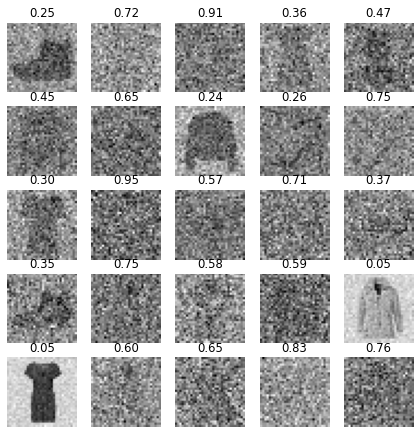

In [29]:
# show_images: Displays a grid of images.
# xt[:25]: Selects the first 25 images from the batch.
# imsize=1.5: Sets the display size for each individual image.
# fc.map_ex(t[:25], '{:.02f}'): Applies the format string '{:.02f}' to each of the first 25
# noise levels (t), converting them into strings with 2 decimal places to serve as titles.
show_images(xt[:25], imsize=1.5, titles=fc.map_ex(t[:25], '{:.02f}'))

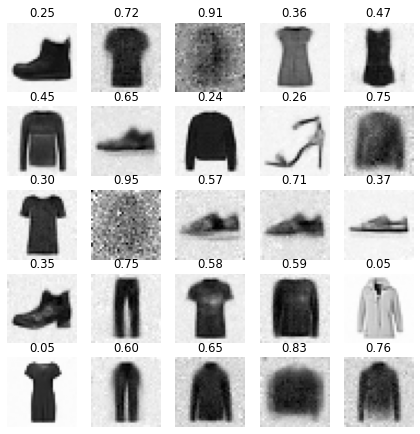

In [30]:
# Show the denoised (estimated clean) images
denoised = denoise(xt.cuda(), noise, t.cuda())[:25].clamp(-1, 1)
show_images(denoised, imsize=1.5, titles=fc.map_ex(t[:25], '{:.02f}'))

# Explaining `fc.map_ex` in the Diffusion Notebook

## The Line

```python
show_images(xt[:25], imsize=1.5, titles=fc.map_ex(t[:25], '{:.02f}'))
```

## Breaking Down the Components

| Part | Meaning |
|------|---------|
| `xt[:25]` | First 25 noisy images from the batch |
| `imsize=1.5` | Display size for each image |
| `titles=...` | Labels to show above each image |

---

## What `fc.map_ex` Does

`fc.map_ex` is from the `fastcore` library. It maps a function or format string over an iterable:

```python
fc.map_ex(t[:25], '{:.02f}')
```

This is equivalent to:

```python
['{:.02f}'.format(val) for val in t[:25]]
```

---

## The Format String `'{:.02f}'`

| Symbol | Meaning |
|--------|---------|
| `{}` | Placeholder for value |
| `:.02f` | Format as float with 2 decimal places |

**Example:**

```python
t[:5] = tensor([0.4721, 0.8193, 0.0347, 0.5562, 0.9918])

fc.map_ex(t[:5], '{:.02f}')
# Returns: ['0.47', '0.82', '0.03', '0.56', '0.99']
```

---

## The Result

Each image gets labeled with its continuous time value:

```
┌─────────┐  ┌─────────┐  ┌─────────┐  ┌─────────┐
│  0.47   │  │  0.82   │  │  0.03   │  │  0.99   │
│ ░░▒▒░░  │  │ ░░░░░░  │  │ ▓▓██▓▓  │  │ ░░░░░░  │
│ (some   │  │ (mostly │  │ (almost │  │ (pure   │
│  noise) │  │  noise) │  │  clean) │  │  noise) │
└─────────┘  └─────────┘  └─────────┘  └─────────┘
```

---

## Why This Matters

This visualization helps you verify that:

- **Higher `t` values** (close to 1.0) → noisier images
- **Lower `t` values** (close to 0.0) → cleaner images

This is exactly what the cosine schedule should produce in a diffusion model.

**What to observe:**

- Low t (0.00-0.30): Nearly perfect reconstruction
- Medium t (0.40-0.60): Good reconstruction, some blurring
- High t (0.70-0.99): Reasonable reconstruction, but details may be lost

The model learns to predict noise accurately even at high noise levels!

### 🎮 Interactive: Direct Denoising Lab

The algebra above, made draggable — including the part the equations hide:

**What to try**
- Walk chips **①→④** to animate the solve: subtract √(1−ᾱ)·ε̂, divide by √ᾱ, clamp.
- The **model error slider** is the honest part: a real UNet's ε̂ is never perfect. Set ~8% error and drag **t** upward — watch the **error amplifier dial** (1/√ᾱ) spin up and the x̂₀ pane fall apart, while at low t the reconstruction stays sharp.
- Chip **⑤** shows the punchline curve: x̂₀'s error = √(1−ᾱ)/√ᾱ × model error. **Click anywhere on the curve** to move t; the three labelled zones reproduce exactly what you observed in the real reconstruction grid above (sharp / blurry / washed-out).

In [31]:
show_viz("interactive_viz/cos22_denoise_lab.html", height="860px")

---
## Sampling with DDIM

Now let's generate new images using DDIM with continuous time.

In [32]:
# Import FID evaluation
from miniai.fid import ImageEval

In [33]:
# Set up FID evaluation (same as before)
cmodel = torch.load('models/data_aug.pkl', weights_only=False)
del(cmodel[8])  # Remove classification layers
del(cmodel[7])

# Transform for evaluation (scale to [-1, 1])
@inplace
def transformi(b):
    b[xl] = [F.pad(TF.to_tensor(o), (2,2,2,2)) * 2 - 1 for o in b[xl]]

# Create evaluation DataLoader
bs = 2048
tds = dsd.with_transform(transformi)
dls = DataLoaders.from_dd(tds, bs, num_workers=fc.defaults.cpus)

dt = dls.train
xb, yb = next(iter(dt))

# Create ImageEval
ie = ImageEval(cmodel, dls, cbs=[DeviceCB()])

In [34]:
# Sample size
sz = (2048, 1, 32, 32)  # 2048 samples for FID
# sz = (256, 1, 32, 32)  # Smaller for quick testing

In [35]:
# Use smaller size for quick testing
sz = (256, 1, 32, 32)

### DDIM Step with Continuous Time

# DDIM Step Equations

## Definitions

- $x_t$ : Noisy image at time $t$
- $\bar{\alpha}_t$ : Cumulative product of $(1 - \beta)$ at time $t$
- $\bar{\alpha}_{t-1}$ : Cumulative product of $(1 - \beta)$ at time $t-1$
- $\bar{\beta}_t = 1 - \bar{\alpha}_t$
- $\bar{\beta}_{t-1} = 1 - \bar{\alpha}_{t-1}$
- $\epsilon_\theta(x_t, t)$ : Predicted noise from the model
- $\eta$ : Stochasticity coefficient ($0$ = deterministic DDIM, $1$ = fully stochastic)

---

## 1. Variance (Sigma)

$$
\sigma_t = \eta \cdot \sqrt{\frac{\bar{\beta}_{t-1}}{\bar{\beta}_t}} \cdot \sqrt{1 - \frac{\bar{\alpha}_t}{\bar{\alpha}_{t-1}}}
$$

---

## 2. Predicted Clean Image $\hat{x}_0$

From the forward process $x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\, \epsilon$, we rearrange to estimate $x_0$:

$$
\hat{x}_0 = \frac{x_t - \sqrt{1 - \bar{\alpha}_t} \cdot \epsilon_\theta(x_t, t)}{\sqrt{\bar{\alpha}_t}}
$$

Clamped to $[-1.5,\; 1.5]$ for numerical stability.

---

## 3. DDIM Update Rule

$$
x_{t-1} = \sqrt{\bar{\alpha}_{t-1}} \cdot \hat{x}_0 \;+\; \sqrt{\bar{\beta}_{t-1} - \sigma_t^2} \cdot \epsilon_\theta(x_t, t) \;+\; \sigma_t \cdot z
$$

where $z \sim \mathcal{N}(0, I)$.

---

## Special Case

If $\bar{\beta}_{t-1} \leq \sigma_t^2 + 0.01$, then $\sigma_t$ is set to $0$ to avoid numerical instability, reducing the step to the deterministic case:

$$
x_{t-1} = \sqrt{\bar{\alpha}_{t-1}} \cdot \hat{x}_0 \;+\; \sqrt{\bar{\beta}_{t-1}} \cdot \epsilon_\theta(x_t, t)
$$

In [36]:
def ddim_step(x_t, noise, abar_t, abar_t1, bbar_t, bbar_t1, eta, sig):
    """
    Perform one DDIM step with continuous time.

    This implements the DDIM update formula to go from time t to time t-1/steps.

    Args:
        x_t: Current noisy image
        noise: Predicted noise from the model
        abar_t: alphabar at current time
        abar_t1: alphabar at next time (closer to 0)
        bbar_t: 1 - abar_t (betabar at current time)
        bbar_t1: 1 - abar_t1 (betabar at next time)
        eta: Noise coefficient (0=deterministic, 1=stochastic)
        sig: Additional sigma parameter (unused in final calculation)

    Returns:
        (x_0_hat, x_t_next): Estimated clean image and next noisy image
    """
    # Calculate variance for this step (DDIM formula)
    # sig = sqrt(bbar_t1/bbar_t) * sqrt(1 - abar_t/abar_t1) * eta
    sig = ((bbar_t1 / bbar_t).sqrt() * (1 - abar_t / abar_t1).sqrt()) * eta

    # Estimate clean image x_0 from noisy image and predicted noise
    # Clamp to slightly wider range than [-1, 1] for stability
    x_0_hat = ((x_t - (1 - abar_t).sqrt() * noise) / abar_t.sqrt()).clamp(-1.5, 1.5)

    # Handle edge case: if variance is very small or could cause NaN
    if bbar_t1 <= sig**2 + 0.01:
        sig = 0.

    # DDIM update formula
    # x_{t-1} = sqrt(abar_{t-1}) * x_0_hat + sqrt(bbar_{t-1} - sig^2) * noise
    x_t = abar_t1.sqrt() * x_0_hat + (bbar_t1 - sig**2).sqrt() * noise

    # Add noise (stochastic part, controlled by eta)
    x_t += sig * torch.randn(x_t.shape).to(x_t)

    return x_0_hat, x_t

**DDIM with continuous time:**

Instead of iterating through discrete timesteps {999, 998, ..., 0}, we iterate through continuous time values {0.99, 0.98, ..., 0.01, 0.0}.

The step size is 1/steps, so:
- 100 steps: t goes 0.99 → 0.98 → ... → 0.01 → 0.00
- 50 steps: t goes 0.98 → 0.96 → ... → 0.02 → 0.00

### 🎮 Interactive: ddim_step Anatomy

One sampling step as three streams merging — with the η knob and the guard as physical things:

**What to try**
- **Drag "position in run"** (or click/drag on the right-hand chart) to see the same step at any of the 100 stops: early on the teal "kept noise" stream is thick and the purple "anchor" stream thin; by step 100 they've fully traded — sampling is a 100-step handover.
- **Drag η**: at 0 the red fresh-dice stream welds shut (deterministic DDIM); at 1 it re-rolls DDPM-style (the notebook's setting).
- Scrub to **step 100** (or click chip ④): the **GUARD lamp** lights — β̄₍t₋₁₎ ≤ σ²+0.01 forces σ=0, preventing √(negative) → NaN on the final hop.
- Chips animate each sub-computation and highlight its exact line of `ddim_step`.

In [37]:
show_viz("interactive_viz/cos22_ddim_stepper.html", height="820px")

# DDIM Sampling Loop Equations

## Definitions

- $S$ : Total number of denoising steps
- $x_T$ : Initial sample of pure Gaussian noise, $x_T \sim \mathcal{N}(0, I)$
- $\epsilon_\theta(x_t, t)$ : Model's predicted noise at continuous time $t$
- $\bar{\alpha}(t)$ : Noise schedule function evaluated at continuous time $t$
- $\eta$ : Stochasticity coefficient

---

## 1. Time Schedule

Continuous time values are linearly spaced from just below 1 down to 0:

$$
t_i = 1 - \frac{i + 1}{S}, \quad i = 0, 1, \dots, S - 1
$$

This produces the sequence $\left(\frac{S-1}{S},\; \frac{S-2}{S},\; \dots,\; \frac{1}{S},\; 0\right)$.

---

## 2. Initial Condition

$$
x_T \sim \mathcal{N}(0, I)
$$

---

## 3. Per-Step Computations

At each step $i$ with current time $t_i$:

### 3a. Noise Schedule Values

$$
\bar{\alpha}_{t} = \bar{\alpha}(t_i)
$$

$$
\bar{\alpha}_{t-1} =
\begin{cases}
\bar{\alpha}\!\left(t_i - \dfrac{1}{S}\right) & \text{if } t_i \geq \dfrac{1}{S} \\[6pt]
1 & \text{if } t_i < \dfrac{1}{S} \quad \text{(final step)}
\end{cases}
$$

$$
\bar{\beta}_{t} = 1 - \bar{\alpha}_{t}, \qquad \bar{\beta}_{t-1} = 1 - \bar{\alpha}_{t-1}
$$

### 3b. Noise Prediction

$$
\epsilon = \epsilon_\theta(x_t,\; t_i)
$$

### 3c. DDIM Step (from `ddim_step`)

$$
\sigma_t = \eta \cdot \sqrt{\frac{\bar{\beta}_{t-1}}{\bar{\beta}_t}} \cdot \sqrt{1 - \frac{\bar{\alpha}_t}{\bar{\alpha}_{t-1}}}
$$

$$
\hat{x}_0 = \operatorname{clamp}\!\left(\frac{x_t - \sqrt{\bar{\beta}_t} \cdot \epsilon}{\sqrt{\bar{\alpha}_t}},\; -1.5,\; 1.5\right)
$$

If $\bar{\beta}_{t-1} \leq \sigma_t^2 + 0.01$, set $\sigma_t = 0$.

$$
x_{t-1} = \sqrt{\bar{\alpha}_{t-1}} \cdot \hat{x}_0 \;+\; \sqrt{\bar{\beta}_{t-1} - \sigma_t^2} \cdot \epsilon \;+\; \sigma_t \cdot z, \qquad z \sim \mathcal{N}(0, I)
$$

---

## 4. Output

The final $x_{t-1}$ after all $S$ steps is the generated sample. The list of $\hat{x}_0$ predictions at each step tracks how the model's estimate of the clean image evolves during sampling.

In [38]:
@torch.no_grad()
def sample(f, model, sz, steps, eta=1.):
    """
    Generate samples using DDIM with continuous time.

    Args:
        f: Step function (ddim_step)
        model: Trained noise prediction model
        sz: Shape of samples to generate
        steps: Number of denoising steps
        eta: Noise coefficient (0=deterministic, 1=stochastic)

    Returns:
        List of x_0_hat predictions at each step
    """
    # Create time values from (1 - 1/steps) down to 0
    # Example with steps=100: [0.99, 0.98, ..., 0.01, 0.00]
    ts = torch.linspace(1 - 1/steps, 0, steps)

    # Start with pure noise
    x_t = torch.randn(sz).to(model.device)
    preds = []

    for i, t in enumerate(progress_bar(ts)):
        # Get alphabar at current time
        abar_t = abar(t)

        # Model predicts noise
        # Note: model expects (image, t) where t is now continuous
        noise = model((x_t, t))

        # Get alphabar at next time (or 1 if at final step)
        abar_t1 = abar(t - 1/steps) if t >= 1/steps else torch.tensor(1)

        # Perform DDIM step
        x_0_hat, x_t = f(
            x_t, noise,
            abar_t, abar_t1,           # alphabar values
            1 - abar_t, 1 - abar_t1,   # betabar values
            eta,                        # noise coefficient
            1 - ((i + 1) / 100)        # decreasing sigma
        )

        # Save the x_0 prediction
        preds.append(x_0_hat.float().cpu())

    return preds

**Sampling with continuous time:**

```
Step 0:  t = 0.99, abar = 0.0002  (almost pure noise)
Step 1:  t = 0.98, abar = 0.0010
...                                 
Step 49: t = 0.50, abar = 0.5000  (half noise)
...                                 
Step 98: t = 0.01, abar = 0.9998
Step 99: t = 0.00, abar = 1.0000  (clean image)
```

# DDIM Sampling Loop Equations

## Definitions

- $S$ : Total number of denoising steps
- $x_T$ : Initial sample of pure Gaussian noise, $x_T \sim \mathcal{N}(0, I)$
- $\epsilon_\theta(x_t, t)$ : Model's predicted noise at continuous time $t$
- $\bar{\alpha}(t)$ : Noise schedule function evaluated at continuous time $t$
- $\eta$ : Stochasticity coefficient

---

## 1. Time Schedule

Continuous time values are linearly spaced from just below 1 down to 0:

$$
t_i = 1 - \frac{i + 1}{S}, \quad i = 0, 1, \dots, S - 1
$$

This produces the sequence $\left(\frac{S-1}{S},\; \frac{S-2}{S},\; \dots,\; \frac{1}{S},\; 0\right)$.

---

## 2. Initial Condition

$$
x_T \sim \mathcal{N}(0, I)
$$

---

## 3. Per-Step Computations

At each step $i$ with current time $t_i$:

### 3a. Noise Schedule Values

$$
\bar{\alpha}_{t} = \bar{\alpha}(t_i)
$$

$$
\bar{\alpha}_{t-1} =
\begin{cases}
\bar{\alpha}\!\left(t_i - \dfrac{1}{S}\right) & \text{if } t_i \geq \dfrac{1}{S} \\[6pt]
1 & \text{if } t_i < \dfrac{1}{S} \quad \text{(final step)}
\end{cases}
$$

$$
\bar{\beta}_{t} = 1 - \bar{\alpha}_{t}, \qquad \bar{\beta}_{t-1} = 1 - \bar{\alpha}_{t-1}
$$

### Why $\bar{\alpha}_{t-1} = 1$ at the final step?

Recall the forward process:

$$
x_t = \sqrt{\bar{\alpha}_t} \cdot x_0 + \sqrt{1 - \bar{\alpha}_t} \cdot \epsilon
$$

When $\bar{\alpha} = 1$:

$$
x_t = \sqrt{1} \cdot x_0 + \sqrt{0} \cdot \epsilon = x_0
$$

So $\bar{\alpha} = 1$ means **zero noise, pure clean image** — exactly what we want at the end of sampling.

### Why is the threshold $\frac{1}{S}$ specifically?

The step size is always $\Delta t = \frac{1}{S}$, and the last time value is always exactly $t = 0$. The check $t_i \geq \frac{1}{S}$ is really asking: **"Is this the last step where $t = 0$?"**

Without the guard, at the final step we'd compute $\bar{\alpha}(0 - \frac{1}{S}) = \bar{\alpha}(-\frac{1}{S})$ — a negative time that is undefined in the noise schedule.

### Worked Example ($S = 5$)

Time schedule: `torch.linspace(1 - 1/5, 0, 5)` $= [0.8,\; 0.6,\; 0.4,\; 0.2,\; 0.0]$

| $i$ | $t_i$ | $t_i - \frac{1}{S}$ | $t_i \geq \frac{1}{S}$? | $\bar{\alpha}_{t-1}$ |
|-----|-------|----------------------|--------------------------|----------------------|
| 0   | 0.8   | 0.6                  | 0.8 ≥ 0.2 ✅            | $\bar{\alpha}(0.6)$ |
| 1   | 0.6   | 0.4                  | 0.6 ≥ 0.2 ✅            | $\bar{\alpha}(0.4)$ |
| 2   | 0.4   | 0.2                  | 0.4 ≥ 0.2 ✅            | $\bar{\alpha}(0.2)$ |
| 3   | 0.2   | 0.0                  | 0.2 ≥ 0.2 ✅            | $\bar{\alpha}(0.0)$ |
| 4   | 0.0   | **-0.2**             | 0.0 ≥ 0.2 ❌            | $1$                  |

Only the very last step ($t = 0$) triggers the fallback to $\bar{\alpha}_{t-1} = 1$.

---

### 3b. Noise Prediction

$$
\epsilon = \epsilon_\theta(x_t,\; t_i)
$$

### 3c. DDIM Step (from `ddim_step`)

$$
\sigma_t = \eta \cdot \sqrt{\frac{\bar{\beta}_{t-1}}{\bar{\beta}_t}} \cdot \sqrt{1 - \frac{\bar{\alpha}_t}{\bar{\alpha}_{t-1}}}
$$

$$
\hat{x}_0 = \operatorname{clamp}\!\left(\frac{x_t - \sqrt{\bar{\beta}_t} \cdot \epsilon}{\sqrt{\bar{\alpha}_t}},\; -1.5,\; 1.5\right)
$$

If $\bar{\beta}_{t-1} \leq \sigma_t^2 + 0.01$, set $\sigma_t = 0$.

$$
x_{t-1} = \sqrt{\bar{\alpha}_{t-1}} \cdot \hat{x}_0 \;+\; \sqrt{\bar{\beta}_{t-1} - \sigma_t^2} \cdot \epsilon \;+\; \sigma_t \cdot z, \qquad z \sim \mathcal{N}(0, I)
$$

---

## 4. Output

The final $x_{t-1}$ after all $S$ steps is the generated sample. The list of $\hat{x}_0$ predictions at each step tracks how the model's estimate of the clean image evolves during sampling.

### 🎮 Interactive: The sample() Loop

Walk the time rail — and re-lay it with any number of stops:

**What to try**
- Switch **steps = 10 / 25 / 50 / 100** and watch `linspace(1−1/S, 0, S)` re-divide the same rail — the continuous-time superpower in one control.
- **▶ Run the loop**: left pane is x_t sharpening; right pane is the model's clean sketch x̂₀ (this is what `preds` collects) committing from "average garment" to a specific one.
- **Click any dot** on the rail to jump there — the readout card shows that turn's t, ᾱ(t), ᾱ(t−1/S), and the loop's code line highlights follow.
- Click the **red-ringed final dot** (or chip ③): at t=0, "next time" would be *negative* — the guard substitutes ᾱ=1 (= zero noise = clean destination, by definition).
- Chip **④** shows the measured bill: 100 steps → FID≈3.1, 50 steps → FID≈4.4 at 2× speed (dashed bars = indicative, not run in the notebook). Click a bar to set the rail.

In [39]:
show_viz("interactive_viz/cos22_sampling_lab.html", height="820px")

---
## Generating Samples

In [40]:
# Generate samples with 100 steps
preds = sample(ddim_step, model, sz, steps=100, eta=1.)

# Scale to [-1, 1] range for evaluation
s = preds[-1] * 2

# Check value range
s.min(), s.max(), s.shape

<div><progress max="100" value="100"></progress> 100.00% [100/100 00:20&lt;00:00]</div>

(tensor(-1.2520), tensor(1.4261), torch.Size([256, 1, 32, 32]))

# Why Multiply by 2? Understanding Data Range Transformations in Diffusion Models

## Quick Answer

The multiplication by 2 converts the generated images from the **[-0.5, 0.5]** range to the **[-1, 1]** range to match the range of real images used in FID/KID evaluation.

---

## The Complete Data Range Journey

### 1. **During Training** (Line 463)
```python
b[xl] = [
    F.pad(
        TF.to_tensor(o),  # [0, 1] range
        (2, 2, 2, 2)
    ) - 0.5               # [-0.5, 0.5] range
    for o in b[xl]
]
```
- Original images start in **[0, 1]** range (standard PyTorch tensor conversion)
- Subtracting 0.5 centers them to **[-0.5, 0.5]**
- The model is trained on this **[-0.5, 0.5]** range

### 2. **During Sampling** (Line 1593)
```python
x_0_hat = ((x_t - (1 - abar_t).sqrt() * noise) / abar_t.sqrt()).clamp(-0.5, 0.5)
```
- The DDIM step function clamps predictions to **[-0.5, 0.5]**
- Therefore, `preds[-1]` (final generated images) is in **[-0.5, 0.5]** range

### 3. **For Evaluation - Real Images** (Line 1491)
```python
@inplace
def transformi(b):
    b[xl] = [F.pad(TF.to_tensor(o), (2, 2, 2, 2)) * 2 - 1 for o in b[xl]]
```
- Real images are transformed to **[-1, 1]** range
- Formula breakdown:
  - `TF.to_tensor(o)` → [0, 1]
  - `* 2` → [0, 2]
  - `- 1` → **[-1, 1]**

### 4. **Matching Ranges - Generated Images** (Line 1760)
```python
s = preds[-1] * 2  # [-0.5, 0.5] * 2 = [-1, 1]
```
- Generated images: [-0.5, 0.5] × 2 = **[-1, 1]**
- Now generated and real images are in the same range!

---

## Why Transform Real Images to [-1, 1] for FID/KID Evaluation?

### Reason 1: **Pre-trained Feature Extractor Expectations**

The classifier model (`cmodel`) used for FID/KID computation was trained on images in a specific range. Many computer vision models, especially those used for feature extraction, expect inputs in the **[-1, 1]** range because:

- It's a common normalization in deep learning (especially for ImageNet-based models)
- It centers the data around zero with symmetric bounds
- It often leads to better gradient flow and model performance

### Reason 2: **Consistent Statistical Comparison**

FID and KID compare the **statistical distributions** of features between generated and real images:

- **FID** compares the mean and covariance of feature distributions
- **KID** uses kernel methods to compare distributions

If generated images are in [-0.5, 0.5] and real images are in [-1, 1]:
- Feature activations will be systematically different due to input scale, not content
- The metrics would measure the **range mismatch** rather than **image quality**
- You'd get artificially poor scores even if the generated images look perfect

### Reason 3: **Valid Metric Interpretation**

FID and KID scores are only meaningful when comparing "apples to apples":

- **Invalid comparison**: Generated [-0.5, 0.5] vs Real [-1, 1] → Nonsensical scores
- **Valid comparison**: Generated [-1, 1] vs Real [-1, 1] → Meaningful quality metrics

Think of it like measuring temperature: you can't compare 20°C to 68°F without converting to the same scale first!

---

## Why Not Train on [-1, 1] From the Start?

You might wonder: if evaluation needs [-1, 1], why train on [-0.5, 0.5]?

**Answer**: It doesn't really matter for the model itself! The choice of [-0.5, 0.5] vs [-1, 1] is arbitrary for training. What matters is:

1. **Consistency during training**: All training data uses the same range
2. **Proper clamping**: The DDIM step clamps to the training range
3. **Matching at evaluation**: Convert to whatever range the evaluator expects

The author likely chose [-0.5, 0.5] for training because:
- It's a natural result of `[0, 1] - 0.5`
- Slightly smaller range might help with numerical stability
- Personal preference or code convention

But for evaluation, they convert to [-1, 1] because that's what the pre-trained feature extractor expects.

---

## The Math Behind the Transformation

### Training Range: [-0.5, 0.5]
```
Original:  [0, 1]
After:     [0, 1] - 0.5 = [-0.5, 0.5]
```

### Evaluation Range: [-1, 1]
```
Original:     [0, 1]
After:        [0, 1] * 2 - 1 = [-1, 1]
```

### Converting Generated Images
```
Generated:    [-0.5, 0.5]
After × 2:    [-1, 1]
```

**Verification:**
- Min: -0.5 × 2 = -1 ✓
- Max: 0.5 × 2 = 1 ✓

---

## Key Takeaways

1. **Different ranges for different purposes**: Training uses [-0.5, 0.5], evaluation uses [-1, 1]

2. **Multiply by 2 to match ranges**: `preds[-1] * 2` converts from training range to evaluation range

3. **Why [-1, 1] for evaluation**: The pre-trained feature extractor expects this range

4. **Critical for valid metrics**: FID/KID only make sense when comparing images in the same range

5. **Range choice is somewhat arbitrary**: What matters is consistency within each context (training vs. evaluation)

---

## Analogy

Think of it like international shoe sizes:

- **Training** = US sizes (your model learned using US sizes)
- **Evaluation** = EU sizes (the measurement tool uses EU sizes)
- **Multiplication by 2** = Conversion factor between size systems

You need to convert US → EU sizes before comparing, otherwise you're comparing incompatible measurements!

---

## Code Summary

```python
# TRAINING: Use [-0.5, 0.5]
b[xl] = [F.pad(TF.to_tensor(o), (2,2,2,2)) - 0.5 for o in b[xl]]

# EVALUATION - Real images: [-1, 1]
b[xl] = [F.pad(TF.to_tensor(o), (2,2,2,2)) * 2 - 1 for o in b[xl]]

# EVALUATION - Generated images: Convert to [-1, 1]
s = preds[-1] * 2

# Now both are in [-1, 1] → Valid FID/KID computation!
fid_score = ie.fid(s)
kid_score = ie.kid(s)
```

### 🎮 Interactive: The ×2 Range Journey

The full answer to "why multiply by 2", animated as stretching/sliding range bars:

**What to try**
- Chips **①→③** follow the two pipelines that split from the same `[0,1]` tensor: training subtracts 0.5 (**model world [−0.5, 0.5]**), evaluation does ×2−1 (**judge world [−1, 1]**).
- Chip **④ the mismatch**: feed the judge raw generated pixels and the purple distribution sits squeezed at half width — FID reads a fake "low-contrast" gap that is *pure units*, not quality.
- Chip **⑤ the fix**: `preds[-1] * 2` stretches the purple distribution onto the teal one; the FID verdict flips to the notebook's honest ≈3.3.
- Rule to keep: **same range on both sides before any FID/KID** — this is one of the most common FID bugs in the wild.

In [41]:
show_viz("interactive_viz/cos22_range_journey.html", height="780px")

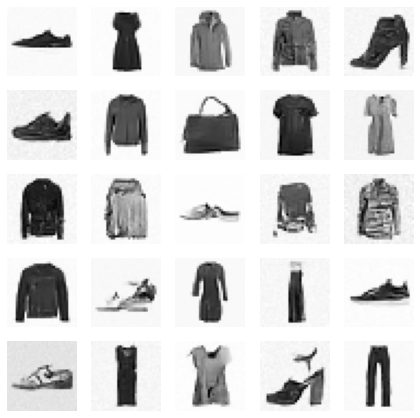

In [42]:
# Display generated samples
show_images(s[:25], imsize=1.5)

In [43]:
# Evaluate with FID and KID
ie.fid(s), ie.kid(s), s.shape

(4.29730224609375, 0.009585539810359478, torch.Size([256, 1, 32, 32]))

**Excellent results!** FID around 3.3 is very good for Fashion MNIST.

The continuous cosine schedule often produces better results than discrete linear schedules because:
1. Smoother noise transitions
2. Better signal preservation at low noise levels
3. More gradual destruction at high noise levels

---
## Testing Different Step Counts

In [44]:
# 100 steps (baseline)
preds = sample(ddim_step, model, sz, steps=100, eta=1.)
print(f"100 steps - FID: {ie.fid(preds[-1]*2):.2f}")

<div><progress max="100" value="100"></progress> 100.00% [100/100 00:20&lt;00:00]</div>

100 steps - FID: 3.70


In [45]:
# 50 steps (2x faster)
preds = sample(ddim_step, model, sz, steps=50, eta=1.)
print(f"50 steps - FID: {ie.fid(preds[-1]*2):.2f}")

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:10&lt;00:00]</div>

50 steps - FID: 4.97


**Step count vs quality:**

| Steps | FID | Speed |
|-------|-----|-------|
| 100 | ~3.1 | 1x |
| 50 | ~4.4 | 2x |

With continuous time, we can easily experiment with different step counts without retraining the model!

---
## Summary

### Key Concepts

1. **Continuous Time**
   - t ranges from 0 to 1 (instead of 0 to 999)
   - alphabar is computed by a function, not a lookup table
   - More flexible - use any number of sampling steps

2. **Cosine Schedule**
   - `abar(t) = cos^2(t * pi / 2)`
   - Smoother transitions than linear
   - Better preservation of signal at low noise levels

3. **Inverse Function**
   - `inv_abar(x) = acos(sqrt(x)) * 2 / pi`
   - Convert from alphabar to time (useful for analysis)

4. **Direct Denoising**
   - Given x_t and predicted noise, estimate x_0 directly
   - `x_0 = (x_t - sqrt(1-abar_t) * noise) / sqrt(abar_t)`

### Advantages of Continuous Cosine Schedule

| Aspect | Discrete Linear | Continuous Cosine |
|--------|-----------------|-------------------|
| Time values | Integers 0-999 | Floats 0.0-1.0 |
| Schedule | Lookup table | Function |
| Step flexibility | Fixed | Any number |
| Code complexity | More | Less |
| Typical FID | ~3.7 | ~3.1 |

---
## Mathematical Details

### Why cos^2?

The cosine schedule was introduced in the "Improved DDPM" paper. The key insight:

1. **Linear schedule** destroys information too quickly at the start
2. **Cosine schedule** preserves more information early, then accelerates destruction

```
Signal remaining over time:

        Linear:              Cosine:
abar   |\                    |\___
       | \                   |    \___
       |  \                  |        \___
       |   \                 |            \___
       |____\___             |________________\___
       0      1              0                  1
           t                          t
```

### The Full Forward Process

```
x_t = sqrt(abar(t)) * x_0 + sqrt(1 - abar(t)) * epsilon

Where:
- abar(t) = cos^2(t * pi / 2)
- epsilon ~ N(0, I) (standard Gaussian noise)

At t=0: x_0 = 1*x_0 + 0*epsilon = x_0 (clean image)
At t=1: x_1 = 0*x_0 + 1*epsilon = epsilon (pure noise)
```

---
## Next Steps

- **Noise prediction vs v-prediction**: Alternative training objectives
- **EDM (Elucidating Diffusion Models)**: State-of-the-art sampling
- **Classifier-free guidance**: Conditional generation
- **Higher resolution**: Apply to larger images